# Neural Network
- Multiple output heads for different levels
- Weighted cross entropy loss
    -Dynamic weights?

## Module Imports

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary


## Set Torch Device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Data Import

In [3]:
chunksFilePath = Path("GlobalGeoTree-6M/Chunks1Pixel/")

dfTrain = torch.load(chunksFilePath / 'SampledData-10Percent-Clean-Train.pth', map_location="cpu", weights_only=False)
dfTest = torch.load(chunksFilePath / 'SampledData-10Percent-Clean-Test.pth', map_location="cpu", weights_only=False)

In [4]:
dfTrain.head()

,ID,longitude,latitude,elevation,slope,aspect,soil_moisture_0_5cm,soil_moisture_5_15cm,soil_moisture_15_30cm,bio01,...,Band_09_Month_02,Band_09_Month_03,Band_09_Month_04,Band_09_Month_05,Band_09_Month_06,Band_09_Month_07,Band_09_Month_08,Band_09_Month_09,Band_09_Month_10,Band_09_Month_11
0,2197969,0.621170,0.881777,0.040761,0.064935,0.752089,0.794896,0.646840,0.692884,0.183391,...,0.175263,0.263174,0.378152,0.161703,0.186288,0.180966,0.160436,0.193131,0.044354,0.007350
1,2196960,0.739576,0.851944,0.131341,0.129870,0.311978,0.568281,0.524163,0.546816,0.100346,...,0.178178,0.319478,0.270688,0.223673,0.165252,0.228108,0.257255,0.277531,0.186415,0.236979
2,2972526,0.151709,0.827662,0.014266,0.051948,0.250696,0.906460,0.836431,0.741573,0.352941,...,0.155494,0.133950,0.163097,0.640983,0.152199,0.140667,0.111773,0.628944,0.263174,0.050564
3,1605005,0.519282,0.900599,0.016304,0.025974,0.172702,0.575254,0.464684,0.393258,0.283737,...,0.294259,0.308199,0.213661,0.163224,0.157648,0.148650,0.148017,0.127740,0.177417,0.291725
4,582943,0.546077,0.829973,0.048460,0.012987,0.250696,0.271938,0.144981,0.146067,0.356401,...,0.289951,0.268027,0.202256,0.263174,0.176277,0.174883,0.184007,1.000000,0.220504,0.263174


# Data Loading

In [5]:
levelsColumns = [col for col in dfTrain.columns if 'level' in col]
imgDataCols = [col for col in dfTrain.columns if 'Band_' in col]

X_train = dfTrain.drop(columns=levelsColumns+['ID'])
X_test = dfTest.drop(columns=levelsColumns+['ID'])
Y_train = dfTrain[levelsColumns]
Y_test = dfTest[levelsColumns]

In [6]:
batch_size = 128

# Convert features to tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32, device=device)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32, device=device)

# Convert labels to integers and create mapping for each level
label_encoders = {}
y_train_dict = {}
y_test_dict = {}

for col in levelsColumns:
    all_labels = pd.concat([Y_train[col], Y_test[col]])
    uniques = pd.Index(all_labels.unique())
    label_encoders[col] = uniques

    mapping = {label: i for i, label in enumerate(uniques)}

    y_train_dict[col] = torch.tensor(Y_train[col].map(mapping).values, dtype=torch.long, device=device)
    y_test_dict[col] = torch.tensor(Y_test[col].map(mapping).values, dtype=torch.long, device=device)

# Custom dataset class to handle multiple outputs
class MultiLabelDataset(TensorDataset):
    def __init__(self, features, targets_dict):
        self.features = features
        self.targets_dict = targets_dict
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        x = self.features[idx]
        y = {col: self.targets_dict[col][idx] for col in self.targets_dict.keys()}
        return x, y

# Create datasets and dataloaders
train_dataset = MultiLabelDataset(X_train_tensor, y_train_dict)
test_dataset = MultiLabelDataset(X_test_tensor, y_test_dict)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train loader: {len(train_loader)} batches of {batch_size}")
print(f"Test loader: {len(test_loader)} batches of {batch_size}")

Train loader: 3582 batches of 128
Test loader: 898 batches of 128


# Network Definition

## F1 Score

In [7]:
def computeF1Scores(outputs, targets):
    f1_scores = {}
    for level in outputs.keys():
        preds = torch.argmax(outputs[level], dim=1).cpu().numpy()
        trues = targets[level].cpu().numpy()
        
        tp = np.sum((preds == trues) & (trues != -1))
        fp = np.sum((preds != trues) & (preds != -1))
        fn = np.sum((preds != trues) & (trues != -1))
        
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
        
        f1_scores[level] = f1
    return f1_scores

## Loss Function

In [8]:
def weightedLoss(outputs, targets, label_smoothings, weights):
    total_loss = 0.0
    
    # Iterate through each level with its corresponding smoothing and weight
    for idx, level in enumerate(outputs.keys()):

        criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothings[idx])

        # Compute loss for this level
        level_loss = criterion(outputs[level], targets[level])
        
        # Add weighted loss to total
        total_loss += weights[idx] * level_loss
    
    return total_loss

## Class

In [9]:
class NN(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_sizes):
        super(NN, self).__init__()
        # BXFCY: Block X, Fully Connected Layer Y
        # BXFC0 come from previous block output level
        # BXFC1 comes directly from last model state
        
        # Preserve the level key order as provided
        self.level_keys = list(output_sizes.keys())
        
        blockStepper = 0
        self.B0FC1 = nn.Linear(input_size, hidden_sizes[blockStepper])
        self.B0BN1 = nn.BatchNorm1d(hidden_sizes[blockStepper])
        self.B0ReLU1 = nn.ReLU()
        self.B0FC2 = nn.Linear(hidden_sizes[blockStepper], hidden_sizes[blockStepper])
        self.B0BN2 = nn.BatchNorm1d(hidden_sizes[blockStepper])
        self.B0ReLU2 = nn.ReLU()
        
        blockStepper += 1
        self.B1FC1 = nn.Linear(hidden_sizes[blockStepper-1], hidden_sizes[blockStepper])
        self.B1BN1 = nn.BatchNorm1d(hidden_sizes[blockStepper])
        self.B1ReLU1 = nn.ReLU()
        self.B1FC2 = nn.Linear(hidden_sizes[blockStepper], hidden_sizes[blockStepper])
        self.B1BN2 = nn.BatchNorm1d(hidden_sizes[blockStepper])
        self.B1ReLU2 = nn.ReLU()
        self.L0Output = nn.Linear(hidden_sizes[blockStepper], output_sizes['level0'])
        
        blockStepper += 1
        self.B2FC0 = nn.Linear(output_sizes['level0'], hidden_sizes[blockStepper])
        self.B2FC1 = nn.Linear(hidden_sizes[blockStepper-1], hidden_sizes[blockStepper])
        self.B2BN1 = nn.BatchNorm1d(hidden_sizes[blockStepper])
        self.B2ReLU1 = nn.ReLU()
        self.B2FC2 = nn.Linear(hidden_sizes[blockStepper], hidden_sizes[blockStepper])
        self.B2BN2 = nn.BatchNorm1d(hidden_sizes[blockStepper])
        self.B2ReLU2 = nn.ReLU()
        self.L1Output = nn.Linear(hidden_sizes[blockStepper], output_sizes['level1_family'])
        
        blockStepper += 1
        self.B3FC0 = nn.Linear(output_sizes['level1_family'], hidden_sizes[blockStepper])
        self.B3FC1 = nn.Linear(hidden_sizes[blockStepper-1], hidden_sizes[blockStepper])
        self.B3BN1 = nn.BatchNorm1d(hidden_sizes[blockStepper])
        self.B3ReLU1 = nn.ReLU()
        self.B3FC2 = nn.Linear(hidden_sizes[blockStepper], hidden_sizes[blockStepper])
        self.B3BN2 = nn.BatchNorm1d(hidden_sizes[blockStepper])
        self.B3ReLU2 = nn.ReLU()
        self.L2Output = nn.Linear(hidden_sizes[blockStepper], output_sizes['level2_genus'])
        
        blockStepper += 1
        self.B4FC0 = nn.Linear(output_sizes['level2_genus'], hidden_sizes[blockStepper])
        self.B4FC1 = nn.Linear(hidden_sizes[blockStepper-1], hidden_sizes[blockStepper])
        self.B4BN1 = nn.BatchNorm1d(hidden_sizes[blockStepper])
        self.B4ReLU1 = nn.ReLU()
        self.B4FC2 = nn.Linear(hidden_sizes[blockStepper], hidden_sizes[blockStepper])
        self.B4BN2 = nn.BatchNorm1d(hidden_sizes[blockStepper])
        self.B4ReLU2 = nn.ReLU()
        self.L3Output = nn.Linear(hidden_sizes[blockStepper], output_sizes['level3_species'])
        
    def forward(self, x):
        # Block 0 for initial feature processing
        x = self.B0FC1(x)
        #x = self.B0BN1(x)
        x = self.B0ReLU1(x)
        x = self.B0FC2(x)
        #x = self.B0BN2(x)
        x = self.B0ReLU2(x)
        
        # Block 1 for Level 0
        x = self.B1FC1(x)
        #x = self.B1BN1(x)
        x = self.B1ReLU1(x)
        x = self.B1FC2(x)
        #x = self.B1BN2(x)
        x = self.B1ReLU2(x)
        level0_out = self.L0Output(x)
        
        # Block 2 for Level 1
        x_from_level0 = self.B2FC0(level0_out)
        x = self.B2FC1(x)
        x = torch.add(x_from_level0, x)
        x = self.B2BN1(x)
        #x = self.B2ReLU1(x)
        x = self.B2FC2(x)
        #x = self.B2BN2(x)
        x = self.B2ReLU2(x)
        level1_out = self.L1Output(x)
        
        # Block 3 for Level 2
        x_from_level1 = self.B3FC0(level1_out)
        x = self.B3FC1(x)
        x = torch.add(x_from_level1, x)
        #x = self.B3BN1(x)
        x = self.B3ReLU1(x)
        x = self.B3FC2(x)
        #x = self.B3BN2(x)
        x = self.B3ReLU2(x)
        level2_out = self.L2Output(x)
        
        # Block 4 for Level 3
        x_from_level2 = self.B4FC0(level2_out)
        x = self.B4FC1(x)
        x = torch.add(x_from_level2, x)
        #x = self.B4BN1(x)
        x = self.B4ReLU1(x)
        x = self.B4FC2(x)
        #x = self.B4BN2(x)
        x = self.B4ReLU2(x)
        level3_out = self.L3Output(x)
        
        level_outputs = [level0_out, level1_out, level2_out, level3_out]
        outputs = {k: v for k, v in zip(self.level_keys, level_outputs)}
        
        return outputs

## Hyperparameters

In [10]:
epochs = 15

input_size = X_train_tensor.shape[1]
output_sizes = {col: len(label_encoders[col]) for col in levelsColumns}

hidden_sizes = [128, 128, 256, 256, 512] # Hidden layer sizes for each block

labelSmootings = [0.0, 0.0, 0.0, 0.0] # Label smoothing values for CE for each level
lossWeights = np.array([0.4, 0.2, 0.0, 0.0])  # weights for each level loss in total loss calculation
lossWeights /= np.sum(lossWeights)  # Normalize weights

## Model Initialisation

In [11]:
model = NN(input_size, hidden_sizes, output_sizes).to(device)
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)

summary(model, input_size=(input_size,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 128]          18,944
              ReLU-2                  [-1, 128]               0
            Linear-3                  [-1, 128]          16,512
              ReLU-4                  [-1, 128]               0
            Linear-5                  [-1, 128]          16,512
              ReLU-6                  [-1, 128]               0
            Linear-7                  [-1, 128]          16,512
              ReLU-8                  [-1, 128]               0
            Linear-9                    [-1, 4]             516
           Linear-10                  [-1, 256]           1,280
           Linear-11                  [-1, 256]          33,024
      BatchNorm1d-12                  [-1, 256]             512
           Linear-13                  [-1, 256]          65,792
             ReLU-14                  [

# Training Loop

In [12]:
bestF1 = {col: [] for col in levelsColumns}

trainF1Scores = {col: [] for col in levelsColumns}
trainLosses = []
testF1Scores = {col: [] for col in levelsColumns}
testLosses = []

for epoch in range(epochs):
    model.train()
    trainLoss = 0.0
    trainF1Epoch = {col: 0.0 for col in levelsColumns}

    for batch_idx, (data, targets) in enumerate(train_loader):
        data = data.to(device)
        targets = {col: targets[col].to(device) for col in targets.keys()}

        optimiser.zero_grad()
        outputs = model(data)

        loss = weightedLoss(outputs, targets, labelSmootings, lossWeights)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()

        trainLoss += loss.item() * batch_size
        
        # Compute F1 scores for this batch
        batch_f1 = computeF1Scores(outputs, targets)
        for col in levelsColumns:
            trainF1Epoch[col] += batch_f1[col] * data.size(0)
        

    model.eval()
    testLoss = 0.0
    testF1Epoch = {col: 0.0 for col in levelsColumns}
    
    with torch.no_grad():
        for batch_idx, (data, targets) in enumerate(test_loader):
            data = data.to(device)
            targets = {col: targets[col].to(device) for col in targets.keys()}

            outputs = model(data)
            loss = weightedLoss(outputs, targets, labelSmootings, lossWeights)

            testLoss += loss.item() * batch_size
            
            # Compute F1 scores for this batch
            batch_f1 = computeF1Scores(outputs, targets)
            for col in levelsColumns:
                testF1Epoch[col] += batch_f1[col] * data.size(0)
    
    trainLoss /= len(train_loader.dataset)
    testLoss /= len(test_loader.dataset)
    
    # Average F1 scores
    for col in levelsColumns:
        trainF1Epoch[col] /= len(train_loader.dataset)
        testF1Epoch[col] /= len(test_loader.dataset)
        trainF1Scores[col].append(trainF1Epoch[col])
        testF1Scores[col].append(testF1Epoch[col])

    trainLosses.append(trainLoss)
    testLosses.append(testLoss)


    print(f"Epoch {epoch+1} | Train Loss: {trainLoss:.4f} | Test Loss: {testLoss:.4f}")

Epoch 1 | Train Loss: 1.6273 | Test Loss: 1.5759
Epoch 2 | Train Loss: 1.5552 | Test Loss: 1.5448
Epoch 3 | Train Loss: 1.5262 | Test Loss: 1.5155
Epoch 4 | Train Loss: 1.5070 | Test Loss: 1.5003
Epoch 5 | Train Loss: 1.4929 | Test Loss: 1.5020
Epoch 6 | Train Loss: 1.4826 | Test Loss: 1.4800
Epoch 7 | Train Loss: 1.4742 | Test Loss: 1.4756
Epoch 8 | Train Loss: 1.4666 | Test Loss: 1.4682
Epoch 9 | Train Loss: 1.4614 | Test Loss: 1.4741
Epoch 10 | Train Loss: 1.4560 | Test Loss: 1.4634
Epoch 11 | Train Loss: 1.4511 | Test Loss: 1.4564
Epoch 12 | Train Loss: 1.4472 | Test Loss: 1.4549
Epoch 13 | Train Loss: 1.4438 | Test Loss: 1.4487
Epoch 14 | Train Loss: 1.4409 | Test Loss: 1.4515
Epoch 15 | Train Loss: 1.4378 | Test Loss: 1.4495


## Losses and F1 Plot

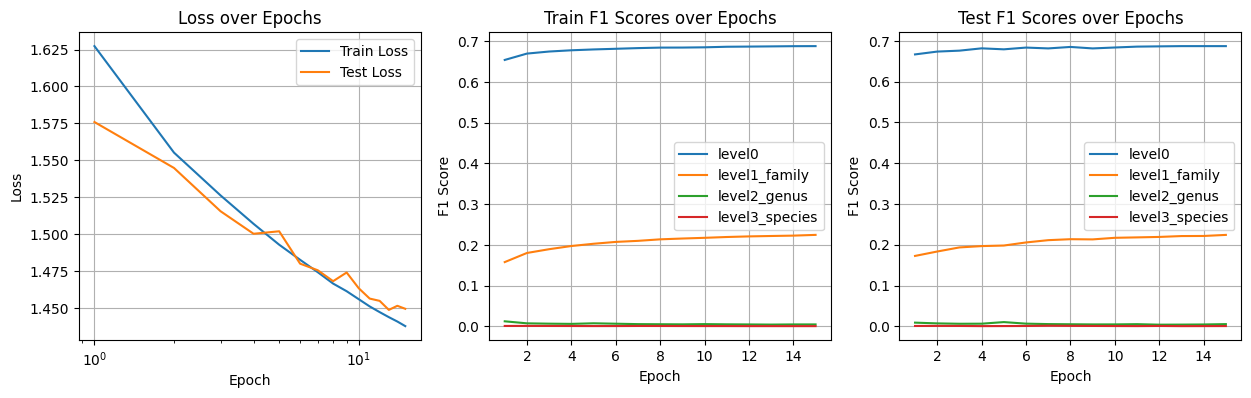

In [14]:
trainLosses = np.array(trainLosses)
testLosses = np.array(testLosses)

figLoss, axLoss = plt.subplots(ncols=3, figsize=(15, 4))

epochArr = np.arange(1, trainLosses.shape[0]+1, 1)

axLoss[0].plot(epochArr, trainLosses, label='Train Loss')
axLoss[0].plot(epochArr, testLosses, label='Test Loss')
axLoss[0].set_title('Loss over Epochs')
axLoss[0].set_xlabel('Epoch')
axLoss[0].set_ylabel('Loss')
axLoss[0].grid()
axLoss[0].set_xscale('log')
axLoss[0].legend()

# Train F1 scores
axTrainF1 = axLoss[1]
for col in levelsColumns:
    axTrainF1.plot(epochArr, trainF1Scores[col], label=f'{col}')

axTrainF1.set_title('Train F1 Scores over Epochs')
axTrainF1.set_xlabel('Epoch')
axTrainF1.set_ylabel('F1 Score')
axTrainF1.grid()
axTrainF1.legend()

# Test F1 scores
axTestF1 = axLoss[2]
for col in levelsColumns:
    axTestF1.plot(epochArr, testF1Scores[col], label=f'{col}')

axTestF1.set_title('Test F1 Scores over Epochs')
axTestF1.set_xlabel('Epoch')
axTestF1.set_ylabel('F1 Score')
axTestF1.grid()
axTestF1.legend()

# To Do

- [] Training loop
- [] loss function
- [] test run on level0 and level1
- [] expand to level2 and level3
- [] hyperparameter tuning
- [] go back to basic model and try to get working
- [] check scales of different parts of cross entropy loss are similar